# Synchronization Analysis With Recurrence Plots

Here we explore which methods from recurrence analysis are well / not well suited for describing synchronization among dynamical systems.
Specifically we want to know which methods based on Cross- and Joint Recurrence Plots reflect characteristics of phase, generalized, (lag) and complete synchronization.

For this purpose we aim to use a canonical dynamical system which can synchronize in all possible ways mentioned above. We test this for the Coupled Roessler System. Kuramoto won't work since it does not have an amplitude or other second component. Short explanation:

Generalized Synchronization is defined as $x_i = F(x_j)$ where $F$ is a functional relationship mapping the states of system j to the states of system i. For the one-dimensional (only phase $\theta$) Kuramoto system this recudes to $\theta_i = F(\theta_j) = \theta_j + \Delta\theta_{ij}$ which is trivial. Generalized synchronization is only mathematically meaningful for systems with more than one dimension

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

# we can use the pyunicorn classes for all types of recurrence plots for convenience
from pyunicorn.timeseries.recurrence_plot import RecurrencePlot
from pyunicorn.timeseries.cross_recurrence_plot import CrossRecurrencePlot
from pyunicorn.timeseries.joint_recurrence_plot import JointRecurrencePlot

### Definition Of The Roessler System

In [2]:
def roessler_coupled(t, X, N, epsilon, A, a=0.2, b=0.2, c=5.7):
    """
    X is a flattened vector [x1, y1, z1, x2, y2, z2, ..., xN, yN, zN] of states for N coupled Roessler systems.
    """
    X = X.reshape(N, 3)
    dX = np.zeros_like(X)
    
    for i in range(N):
        xi, yi, zi = X[i]
        dx = -yi - zi
        dy = xi + a*yi
        dz = b + zi*(xi - c)
        
        coupling_term = epsilon * np.sum(A[i] * (X[:,0] - xi))
        dx += coupling_term
        
        dX[i] = [dx, dy, dz]
    
    return dX.flatten()

In [3]:
# Parametres For The Simulation

N = 3  
a, b, c = 0.2, 0.2, 5.7  
epsilon = 0.01  
T = 200  
dt = 0.1

A = np.ones((N, N)) - np.eye(N) 

In [4]:
# Numerically Integrate The System States

np.random.seed(42)
X0 = np.random.rand(N*3)

t_span = (0, T)
t_eval = np.arange(0, T, dt)

sol = solve_ivp(roessler_coupled, t_span, X0, t_eval=t_eval, args=(N, epsilon, A, a, b, c), method="RK45")

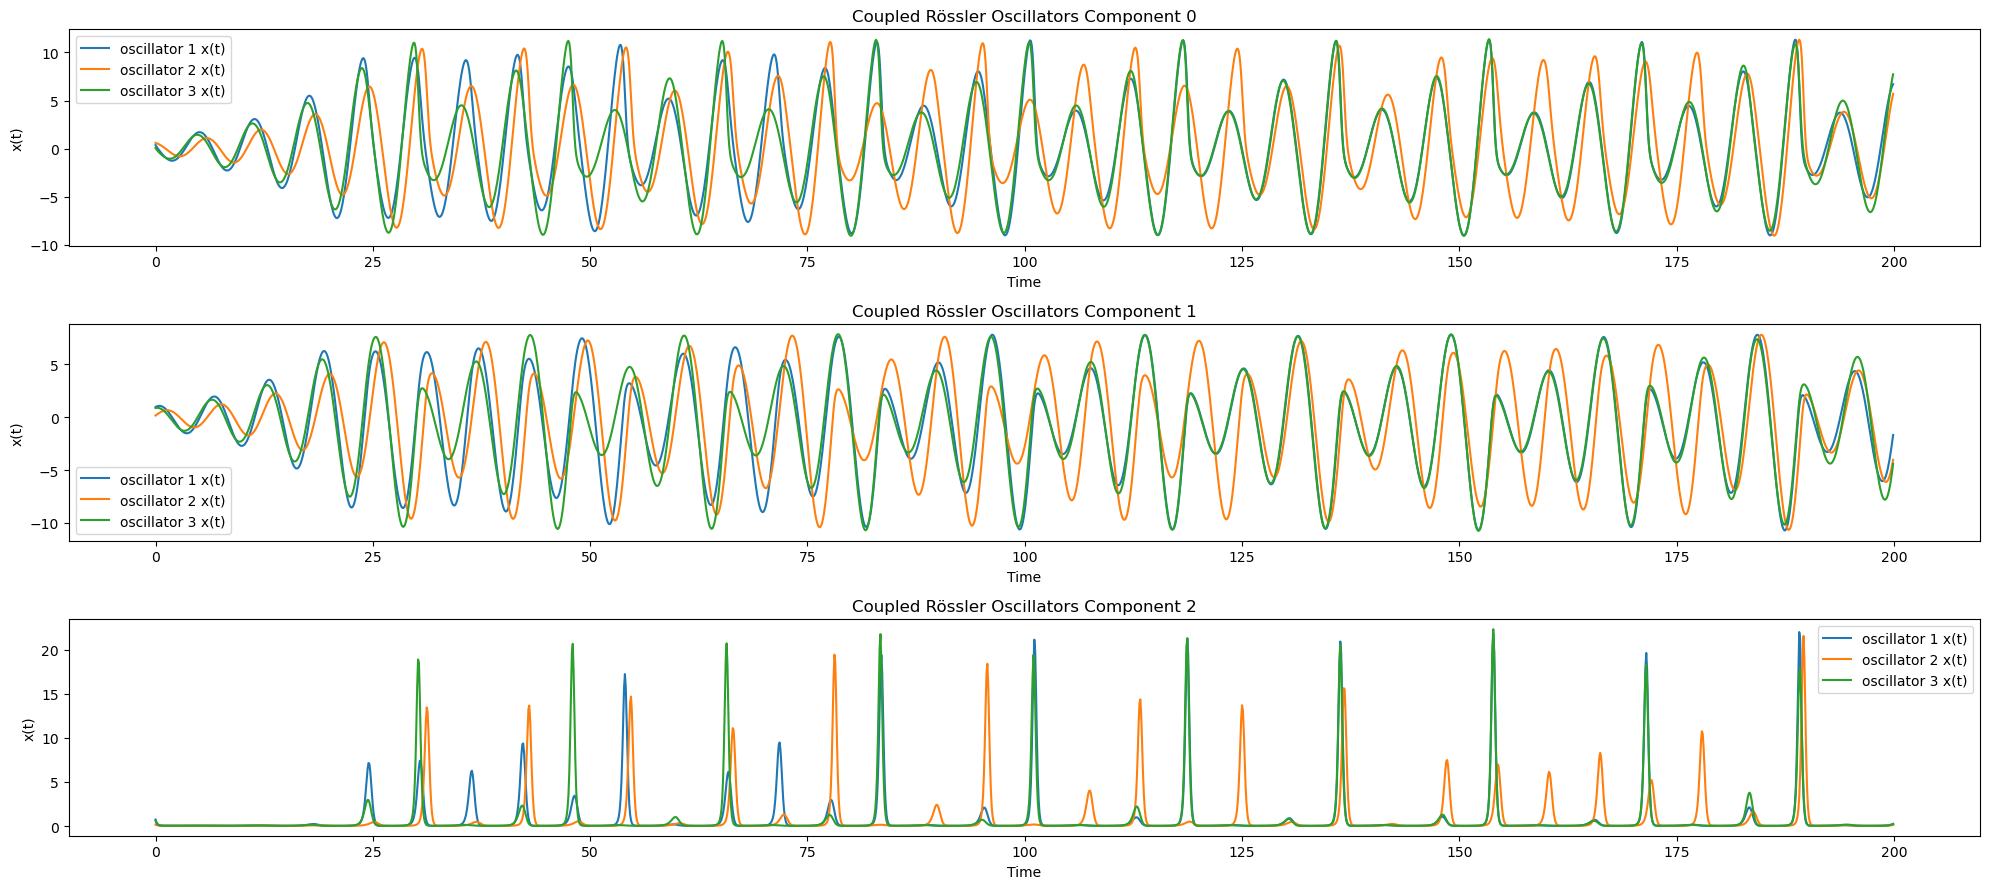

In [5]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(20,9))

for a, comp in zip(ax.flatten(), range(3)):
    for i in range(N):
        a.plot(sol.t, sol.y[comp + i*3], label=f'oscillator {i+1} x(t)')
    a.set_xlabel('Time')
    a.set_ylabel('x(t)')
    a.set_title(f'Coupled Rössler Oscillators Component {comp}')
    a.legend()

plt.tight_layout()
plt.show()

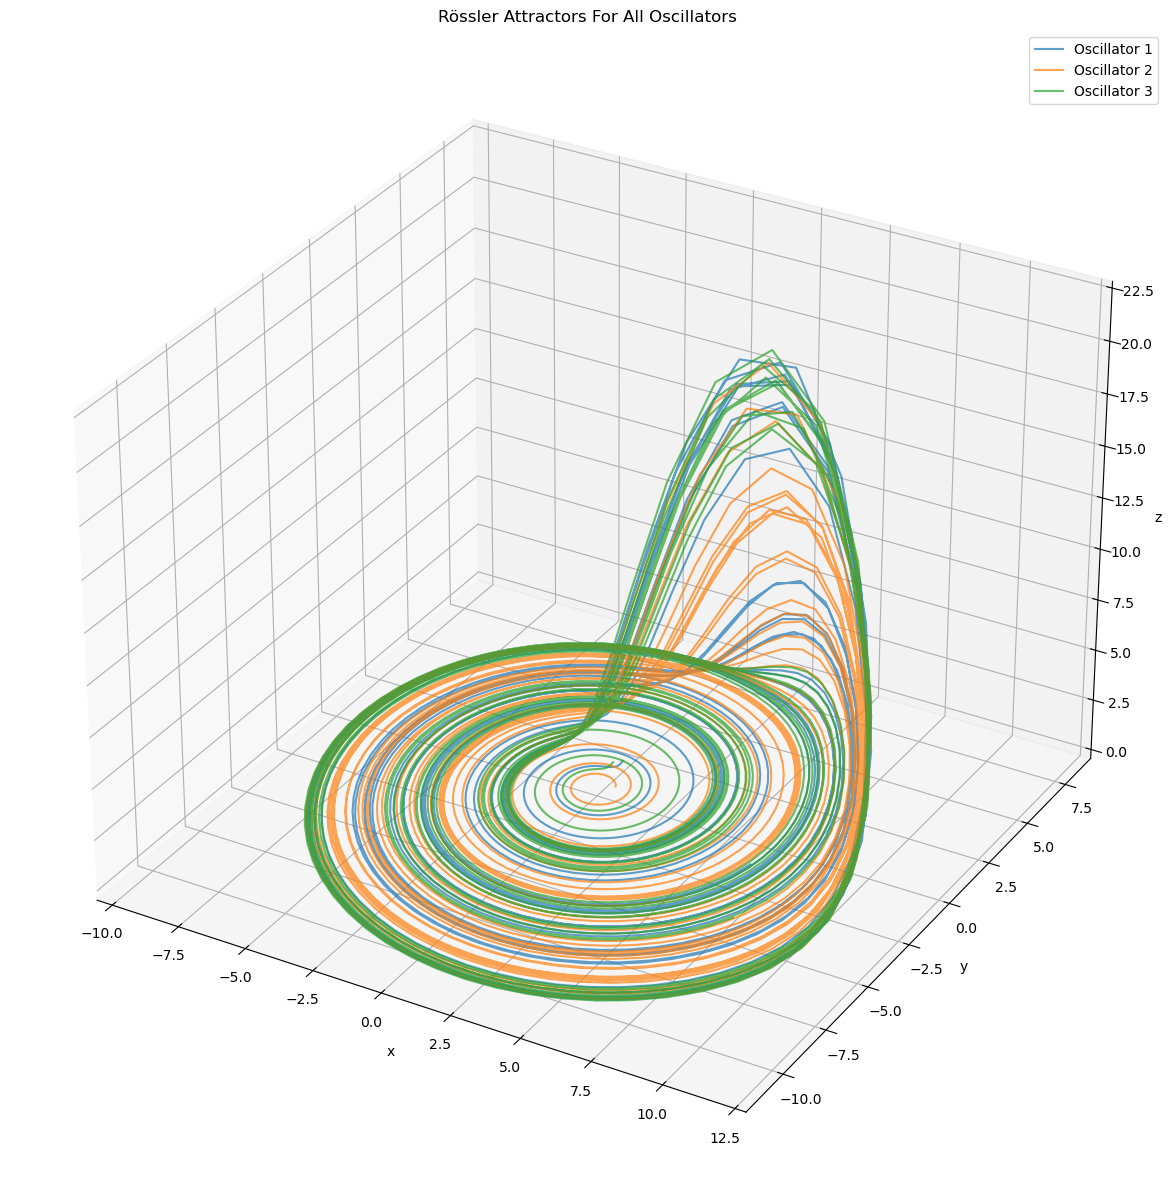

In [6]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(111, projection='3d')

for k in range(N):
    x = sol.y[3*k]
    y = sol.y[3*k + 1]
    z = sol.y[3*k + 2]
    ax.plot(x, y, z, alpha=0.7, label=f"Oscillator {k+1}")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend()
ax.set_title(f"Rössler Attractors For All Oscillators")

plt.show()

### Build A Cross-Recurrence Plot For Two Components Of The System

Calculating cross recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...


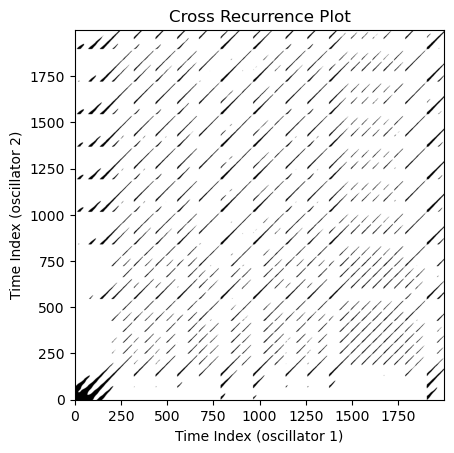

In [7]:
oscillators = (0, 1)

R_C = CrossRecurrencePlot(sol.y[oscillators[0]:oscillators[0]+3].T, sol.y[oscillators[1]*3:oscillators[1]*3+3].T, recurrence_rate=0.05, metric="euclidean")

RMat_C = R_C.recurrence_matrix()

plt.imshow(RMat_C, origin='lower', cmap='binary')
plt.title('Cross Recurrence Plot')
plt.xlabel('Time Index (oscillator 1)')
plt.ylabel('Time Index (oscillator 2)')
plt.show()

### $\tau$-Recurrence Rate

In [27]:
def rr_tau(Rmat, symmetric=False, Rmat2=None, metric="correlation"):

    if symmetric & (Rmat2 is not None):
        counts1 = np.zeros(Rmat.shape[0])
        for i in range(Rmat.shape[0]):
            for (ii, jj) in zip(range(Rmat.shape[0] - i), range(Rmat.shape[0] - i)):
                counts1[i] += Rmat[i + ii, 0 + jj]
            counts1[i] /= (Rmat.shape[0] - i)

        counts2 = np.zeros(Rmat2.shape[0])
        for i in range(Rmat2.shape[0]):
            for (ii, jj) in zip(range(Rmat2.shape[0] - i), range(Rmat2.shape[0] - i)):
                counts2[i] += Rmat2[i + ii, 0 + jj]
            counts2[i] /= (Rmat2.shape[0] - i)

        if metric == "correlation":
            CPR = np.round(np.corrcoef(counts1, counts2)[0, 1], decimals=3)
        elif metric == "hellinger":
            CPR = (1 / np.sqrt(2)) * np.sqrt(np.sum((np.sqrt(counts1) - np.sqrt(counts2)) ** 2))
        elif metric == "jensen_shannon":
            M = 0.5 * (counts1 + counts2)
            CPR = 0.5 * (np.sum(counts1 * np.log(counts1 / M)) + np.sum(counts2 * np.log(counts2 / M)))
        elif metric == "total_variation":
            CPR = 0.5 * np.sum(np.abs(counts1 - counts2))
        elif metric == "wasserstein":
            CPR = np.sum(np.abs(np.cumsum(counts1) - np.cumsum(counts2)))
        elif metric == "bhattacharyya":
            CPR = -np.log(np.sum(np.sqrt(counts1 * counts2)))
        else:
            raise ValueError(f"Unsupported metric: {metric}")

        return {"1": counts1, "2": counts2, "CPR": CPR}
    
    else:
        counts_0 = np.zeros(Rmat.shape[0])
        for i in range(Rmat.shape[0]):
            for (ii, jj) in zip(range(Rmat.shape[0] - i), range(Rmat.shape[0] - i)):
                counts_0[i] += Rmat[i + ii, 0 + jj]
            counts_0[i] /= (Rmat.shape[0] - i)

        counts_1 = np.zeros(Rmat.shape[1])
        for i in range(Rmat.shape[1]):
            for (ii, jj) in zip(range(Rmat.shape[1] - i), range(Rmat.shape[1] - i)):
                counts_1[i] += Rmat[0 + jj, i + ii]
            counts_1[i] /= (Rmat.shape[1] - i)

        CPR = np.round(np.corrcoef(counts_0, counts_1)[0, 1], decimals=3)

        return {"0->1": counts_0, "1->0": counts_1, "CPR": CPR}

## Alternatives to pearson correlation based on probability comparisons:

1. Jensen Shannon Divergence (Symmetric KL-Divergence) $JSD(P,Q) = \frac{1}{2} D_{KL}(P||M)+\frac{1}{2}D_{KL}(Q||M)$

2. Total Variational Distance $D_{TV} = \frac{1}{2}\Sigma_i |P_i - Q_i|$

3. Hellinger Distance $H(Q,P) = \frac{1}{\sqrt{2}}\sqrt{\Sigma_i (\sqrt{P_i} - \sqrt{Q_i})^2}$

4. Bhattacharyya Distance $D_b = -ln(\Sigma_i \sqrt{P_i Q_i})$

5. Wasserstein Distance

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...


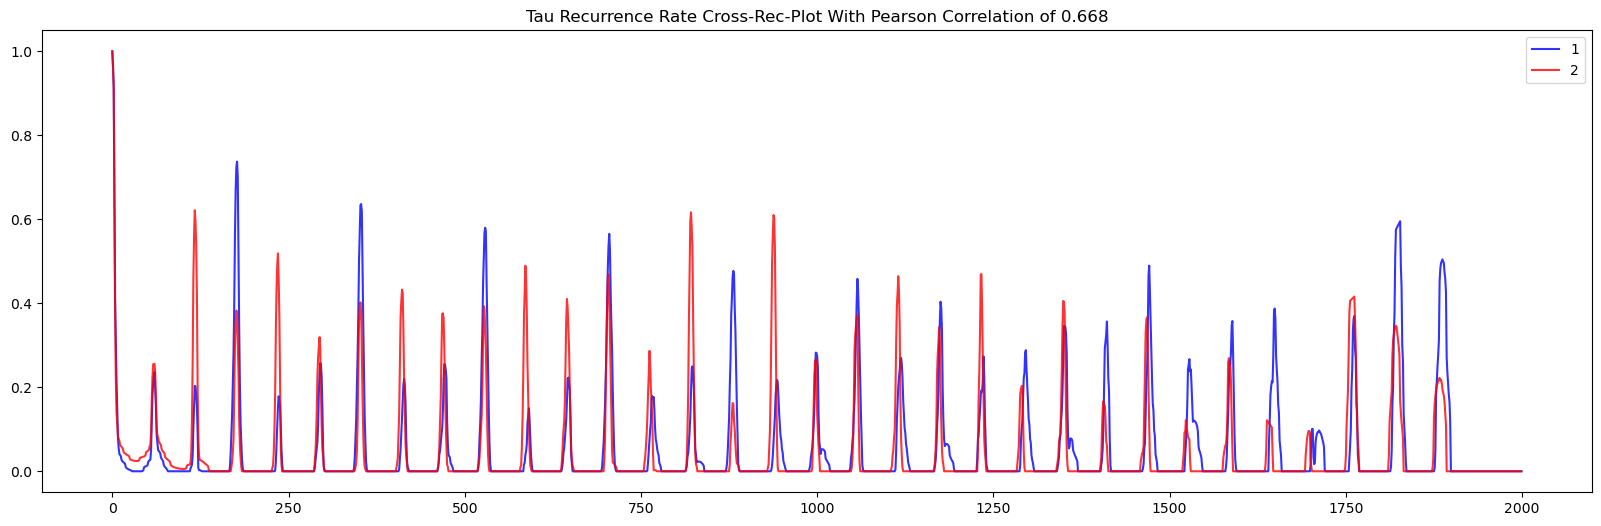

In [26]:
rt = rr_tau(RecurrencePlot(sol.y[0:3, :].T, metric="euclidean", recurrence_rate=0.05).recurrence_matrix(), 
            symmetric=True, 
            Rmat2=RecurrencePlot(sol.y[3:6, :].T, metric="euclidean", recurrence_rate=0.05).recurrence_matrix())

plt.figure(figsize=(20, 6))
plt.plot(rt["1"], c="blue", label="1", alpha=0.8)
plt.plot(rt["2"], c="red", label="2", alpha=0.8)
plt.legend()
plt.title(f"Tau Recurrence Rate Cross-Rec-Plot With Pearson Correlation of {rt["CPR"]}")
plt.show()

Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...


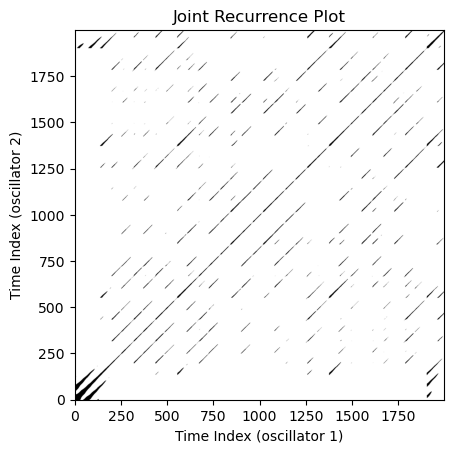

In [250]:
oscillators = (0, 1)

R_J = JointRecurrencePlot(sol.y[oscillators[0]:oscillators[0]+3].T, sol.y[oscillators[1]*3:oscillators[1]*3+3].T,
    recurrence_rate=(0.05,0.05), metric=("euclidean", "euclidean"))

RMat_J = R_J.recurrence_matrix()

plt.imshow(RMat_J, origin='lower', cmap='binary')
plt.title('Joint Recurrence Plot')
plt.xlabel('Time Index (oscillator 1)')
plt.ylabel('Time Index (oscillator 2)')
plt.show()

In [254]:
class R_FAN(RecurrencePlot):
    """
    Returns a recurrence matrix based on a fixed number of nearest neighbors N
    """
    def rfan(self, Nn):
        distance = self.distance_matrix(metric="euclidean")
        N = distance.shape[0]

        R_mod = np.zeros((N, N))

        for i in range(N):
            dist = distance[i].copy()
            dist[i] = np.inf  
            idx = np.argsort(dist)[:Nn]
            R_mod[i, idx] = 1

        return R_mod

def jrp(oscillators, sol, Nn, mode="JPR", max_lag=None, plot=False, component=0, test_lag=0):

    if test_lag != 0:
        ts1, ts2 = sol.y[oscillators[0]:oscillators[0]+3, test_lag:].T, sol.y[oscillators[1]*3:oscillators[1]*3+3, :-test_lag].T
    else:
        ts1, ts2 = sol.y[oscillators[0]:oscillators[0]+3].T, sol.y[oscillators[1]*3:oscillators[1]*3+3].T

    N = ts1.shape[0]
    RR = Nn / N
    
    RF1 = R_FAN(ts1, recurrence_rate=0.05, metric="euclidean")
    Rx = RF1.rfan(Nn)
    RF2 = R_FAN(ts2, recurrence_rate=0.05, metric="euclidean")
    Ry = RF2.rfan(Nn)
    
    if mode == "simple":
        RRxy = np.sum(Rx * Ry) / (N*N)
        S = RRxy / RR

        return S
    
    elif mode == "JPR":
        if max_lag is None:
            raise ValueError("max_lag must be specified for JPR mode")

        s_tau = []
        taus = range(-max_lag, max_lag + 1)

        for tau in taus:

            if tau > 0:
                Rx_sub = Rx[:-tau, :-tau]
                Ry_sub = Ry[tau:, tau:]
            elif tau < 0:
                Rx_sub = Rx[-tau:, -tau:]
                Ry_sub = Ry[:tau, :tau]
            else:
                Rx_sub = Rx
                Ry_sub = Ry

            N_eff = Rx_sub.shape[0]

            RRxy_tau = np.sum(Rx_sub * Ry_sub) / (N_eff * N_eff)
            s_tau.append(RRxy_tau / RR)

        s_tau = np.array(s_tau)

        S_max = np.max(s_tau)
        tau_max = taus[np.argmax(s_tau)]

        JPR = (S_max - RR) / (1 - RR)

        if plot:
            fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(30, 10))
            ax[0].plot(range(-max_lag, max_lag+1), s_tau)
            ax[1].plot(ts1[:,component], label="TS1", c="blue")
            ax[1].plot(ts2[:,component], label="TS2 Normal", ls="--", alpha=0.5, c="red")
            ax[1].plot(range(0-tau_max, ts2.shape[0]-tau_max), ts2[:,component], label="TS2 Lagged", c="red")
            plt.legend()
            plt.show()

        return {"tau": tau_max, "JPR": JPR}

    else:
        print("Choose either 'simple' or 'JPR' as mode")

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...


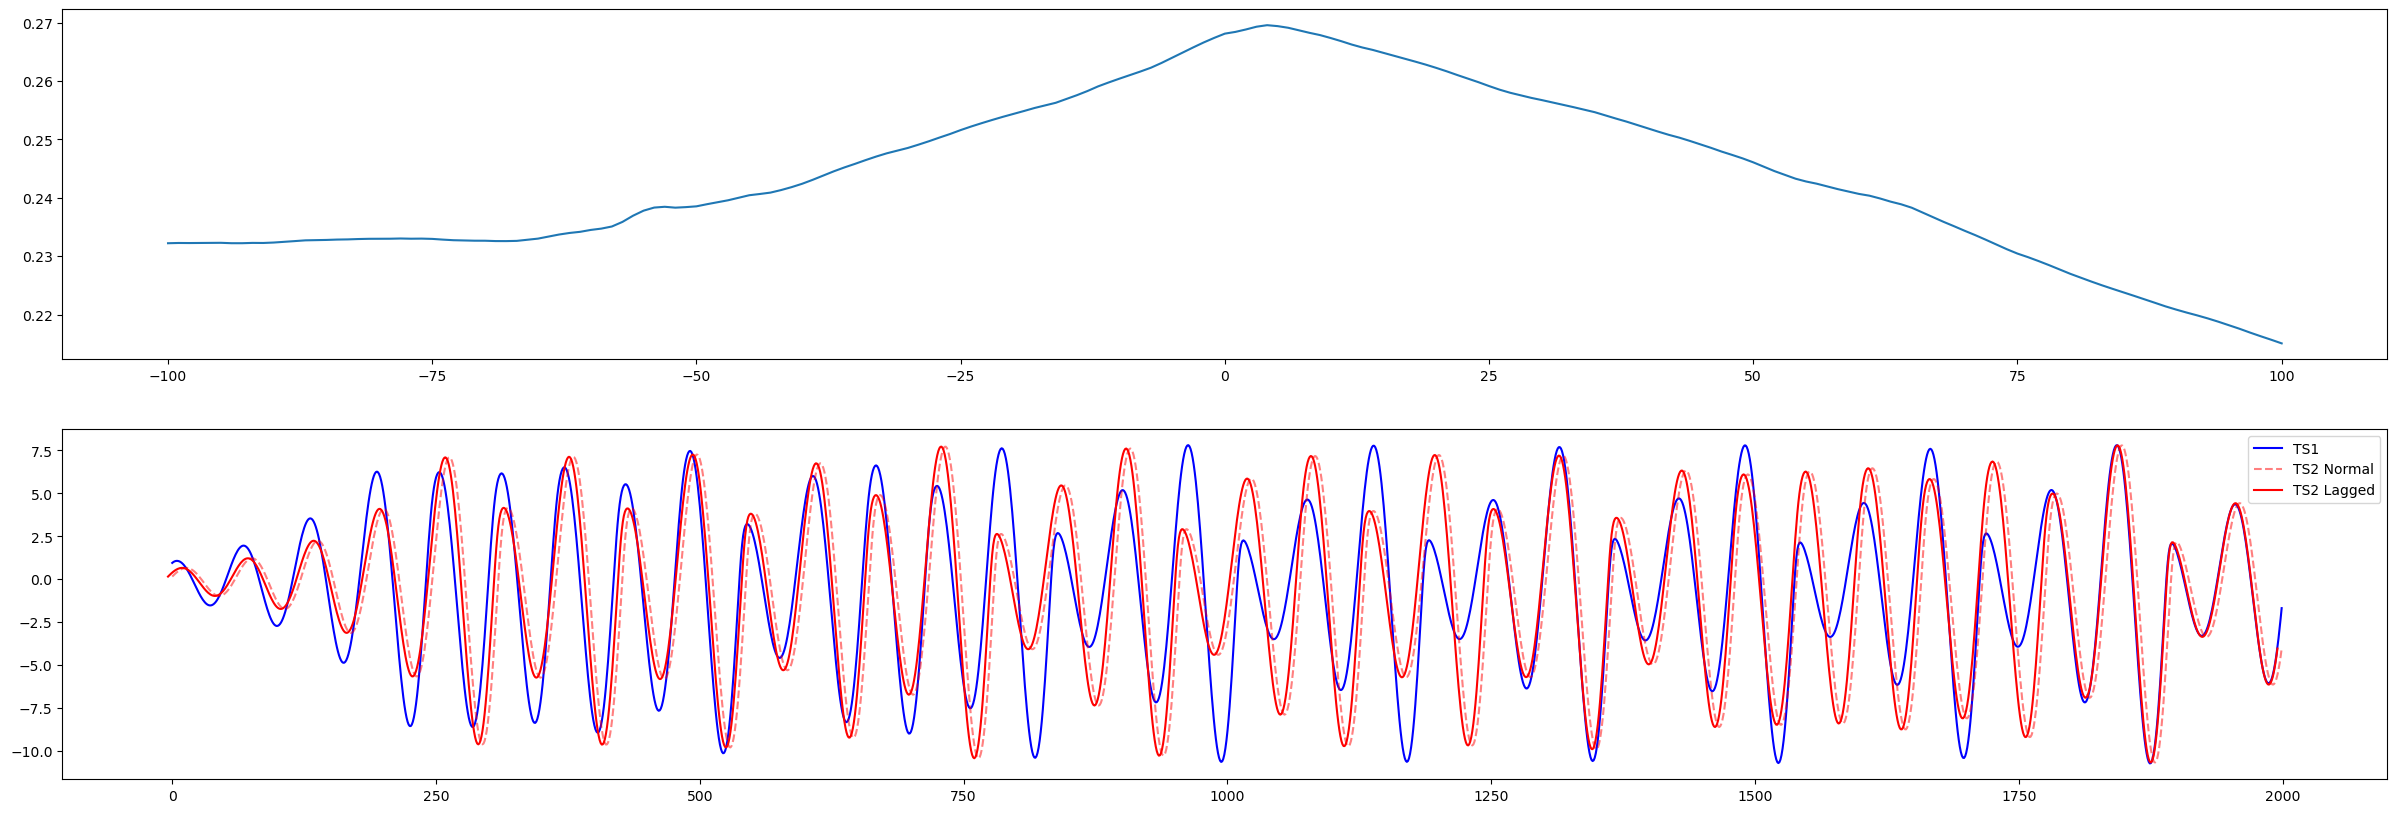

In [255]:
oscillators = (0, 1)

res = jrp(oscillators=oscillators, sol=sol, Nn=50, max_lag=100, plot=True, component=1)

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...


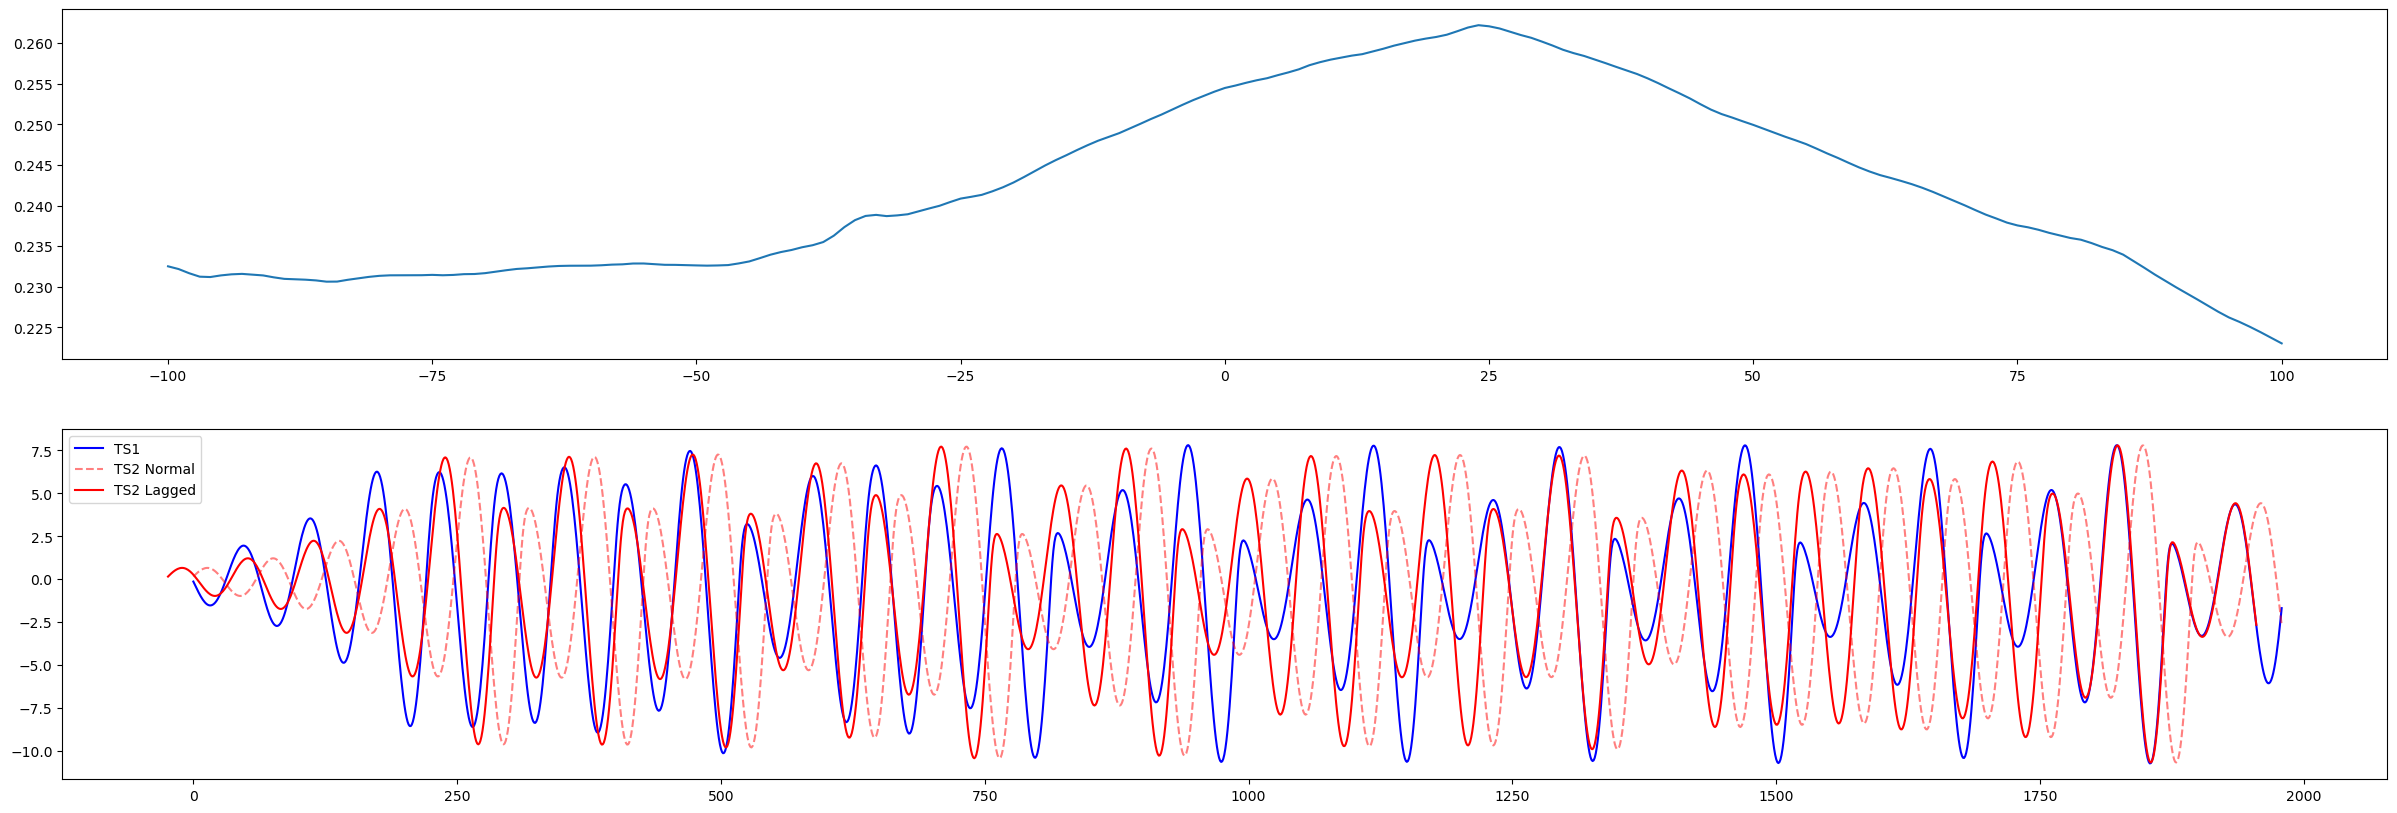

In [256]:
oscillators = (0, 1)
test_lag = 20

res = jrp(oscillators=oscillators, sol=sol, Nn=50, max_lag=100, plot=True, component=1, test_lag=test_lag)